<a href="https://colab.research.google.com/github/marco11235813/Retencion-de-clientes---NoCountry/blob/main/ChurnNC_Prediccion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto: Retención de clientes

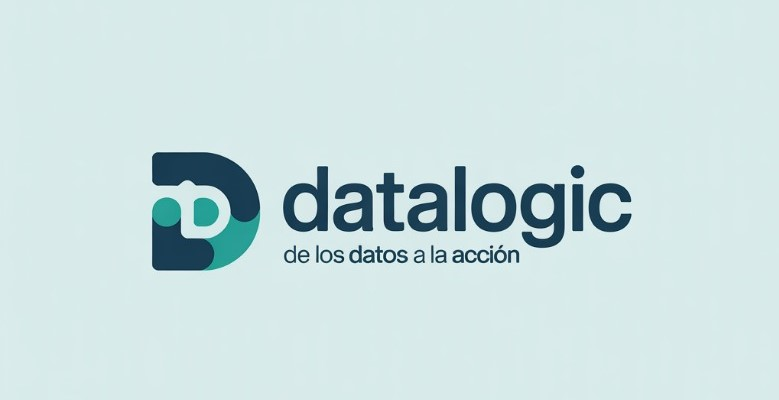

> El dataset **Customer Churn** contiene información de los usuarios de la fintech **InNovaPay**. Cada registro representa un cliente y contiene detalles personales y sobre los movimientos que realiza con InNovaPay
Los datos se han importado de la base de datos que posee la fintech en BigQuery para realizar el preprocesamiento, modelado, predicciones y posteriores conclusiones.
El problema de InNovaPay es la retención de clientes, con los modelos que se realizarán a continuación, se busca identificar aquellos que se encuentren en riesgo de abandono (churn), para poder predecir posteriormente a aquellos que se encuentren en riesgo y  retenerlos mediante insights.



##Importación de librerias que serán utilizadas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
#-------------------------------------------------------------------------------
!pip install scikit-optimize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from skopt import BayesSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc, ConfusionMatrixDisplay
#-------------------------------------------------------------------------------
from sklearn.base import BaseEstimator, TransformerMixin
from sentence_transformers import SentenceTransformer
from skopt.space import Real, Categorical, Integer
from sklearn.neural_network import MLPClassifier

#Carga y revisión  del dataframe

In [ ]:
#Cargo el dataset desde bigQuery
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

from google.cloud import bigquery
client= bigquery.Client(project = 'even-antenna-473123-d3')

query = '''SELECT *
FROM `even-antenna-473123-d3.customer_churn.customer_data`'''
df = client.query(query).to_dataframe()

Authenticated


In [ ]:
#Creo un csv con el dataframe
file_path = '/content/customer_tabla.csv'
df.to_csv(file_path, index=False)

#Modelos

- Seleccionar columnas a utilizar
- Discretizar variables continuas
- Encoding para las categóricas
- Tratamiento de columnas tipo texto
- Pipelines de preprocesamiento
- Prueba de modelos y red neuronal
- Comparativa de métricas
- Elección del mejor modelo
- Generación de pkl para vincular a la app

##Definir target y features
Se definirá la variable objetivo a predecir y las "features" o columnas que se tomarán como predictoras

##División de los datos:train y test

Se crearan dos conjuntos de datos antes de proceder con los pasos subsiguientes.
- Train: Será un conjunto de datos que servirá para entrenar al modelo, utilizando el 80% de los datos.
- Test: Servirá para testear al modelo, se tomará el 20% restante de los datos.


In [ ]:
#Definición de target y las features, descarto las columnas que no se utilizarán

#X como features
x= df_customer[['points_in_wallet', 'avg_transaction_value', 'avg_frequency_login_days', 'avg_tx_amount', 'days_since_last_login', 'feedback', 'membership_category']]
#y como target
y= df_customer['churn_risk_score']

In [ ]:
#Separo los sets
X_train, X_test, y_train, y_test = train_test_split(x, y, stratify=y, random_state=42, test_size=0.2)

#Print
print('X_train shape:', X_train.shape, '\n',
      'X_test shape:', X_test.shape, '\n',
      'y_train shape:', y_train.shape, '\n',
      'y_test shape:', y_test.shape, '\n')

X_train shape: (25308, 7) 
 X_test shape: (6327, 7) 
 y_train shape: (25308,) 
 y_test shape: (6327,) 



In [ ]:
#Columnas a procesar por el modelo
numeric_cols = ['points_in_wallet', 'avg_transaction_value', 'avg_frequency_login_days', 'avg_tx_amount', 'days_since_last_login']
categorical_cols = ['membership_category']
text_col= 'feedback'

In [ ]:
#Para tratar el texto
class BertTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        self.model_name = model_name
        self.model = SentenceTransformer(model_name)

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Asegurar que X es iterable de strings
        if hasattr(X, "iloc"):
            X = X.iloc[:,0]
        elif isinstance(X, list):
            X = pd.Series(X)
        X = X.fillna('').astype(str)
        embeddings = self.model.encode(X.tolist(), show_progress_bar=False)
        return embeddings

In [ ]:
# Transformer de texto
text_transformer = Pipeline([
    ('bert', BertTransformer())
])

# Transformer numérico y categórico
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Pipeline preprocesamiento
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols),
    ('text', text_transformer, [text_col])
])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
#Prueba con modelos ML
models = {
    'RandomForest': (RandomForestClassifier(random_state=42, class_weight='balanced'),
                     {'n_estimators': [100, 200, 300],
                      'max_depth': [None, 10, 20],
                      'min_samples_split': [2, 5, 10]}),
    'XGBoost': (XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42),
                {'n_estimators': [100, 200],
                 'max_depth': [4, 6, 8],
                 'learning_rate': [0.05, 0.1, 0.2]})
}
resultados = []

for name, (model, params) in models.items():
    print(f"\n🔹 Entrenando {name} con BayesianCV...")

    # Pipeline completo: preprocesamiento + modelo
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Ajustar los nombres de parámetros Bayesianos
    bayes_params = {f'model__{key}': value for key, value in params.items()}
    bayes = BayesSearchCV(pipe, bayes_params, n_iter=32, cv=5, scoring='f1', n_jobs=-1, verbose=1)
    bayes.fit(X_train, y_train)

    resultados.append({
        'Modelo': name,
        'Mejores Parámetros': bayes.best_params_,
        'Mejor F1': bayes.best_score_
    })

df_resultados = pd.DataFrame(resultados).sort_values(by='Mejor F1', ascending=False)
display(df_resultados)



🔹 Entrenando RandomForest con BayesianCV...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 f

/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(10), np.int64(2), np.int64(200)] before, using random point [10, 10, 100]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(20), np.int64(5), np.int64(300)] before, using random point [10, 10, 200]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


...

Fitting 5 folds for each of 1 candidates, totalling 5 fits

🔹 Entrenando XGBoost con BayesianCV...


/usr/local/lib/python3.12/dist-packages/skopt/space/space.py:116: UserWarning: Dimension [100, 200] was inferred to Integer(low=100, high=200, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(100, 200), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/space/space.py:116: UserWarning: Dimension [100, 200] was inferred to Integer(low=100, high=200, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(100, 200), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/space/space.py:116: UserWarning: Dimension [100, 200] was inferred to Integer(low=100, high=200, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, 

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:17:57] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Modelo,Mejores Parámetros,Mejor F1
1,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",0.939848
0,RandomForest,"{'model__max_depth': 10, 'model__min_samples_s...",0.934173


In [ ]:
#Nuevo entrenamiento con el mejor modelo y parámetros: XGBOOST
best_modelML= bayes.best_estimator_

# Entrenar el mejor modelo con los datos completos de entrenamiento
best_modelML.fit(X_train, y_train)

# Predecir sobre el set de test
y_prediction = best_modelML.predict(X_test)

#Mostrar
print(classification_report(y_test, y_prediction),
      accuracy_score(y_test, y_prediction))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [02:00:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93      2893
         1.0       0.94      0.95      0.94      3434

    accuracy                           0.94      6327
   macro avg       0.94      0.94      0.94      6327
weighted avg       0.94      0.94      0.94      6327
 0.93630472577841


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [ ]:
# Modelo: MLP
mlp = MLPClassifier(max_iter=200, random_state=42)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', mlp)
])

# Definir espacio de búsqueda
search_spaces = {
    'model__hidden_layer_sizes':  Integer(50, 150),
    'model__activation': Categorical(['relu', 'tanh']),
    'model__alpha': Real(1e-5, 1e-2, prior='log-uniform'),
    'model__learning_rate_init': Real(1e-4, 1e-2, prior='log-uniform')
}

# BayesSearchCV
opt = BayesSearchCV(
    estimator=pipe,                  # Pipeline con preprocessor + MLP
    search_spaces=search_spaces,
    n_iter=15,                       # cantidad de iteraciones
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=2,
    random_state=42
)
#Entrenamiento
opt.fit(X_train, y_train)
print("Best params:", opt.best_params_)
print("Best F1:", opt.best_score_)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best params: OrderedDict({'model__activation': 'tanh', 'model__alpha': 0.004466278825224283, 'model__hidden_layer_s

In [ ]:
#Mejor modelo MLP
best_model = opt.best_estimator_
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred),
      accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.95      0.90      0.92      2893
         1.0       0.92      0.96      0.94      3434

    accuracy                           0.93      6327
   macro avg       0.93      0.93      0.93      6327
weighted avg       0.93      0.93      0.93      6327
 0.9328275644065118


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


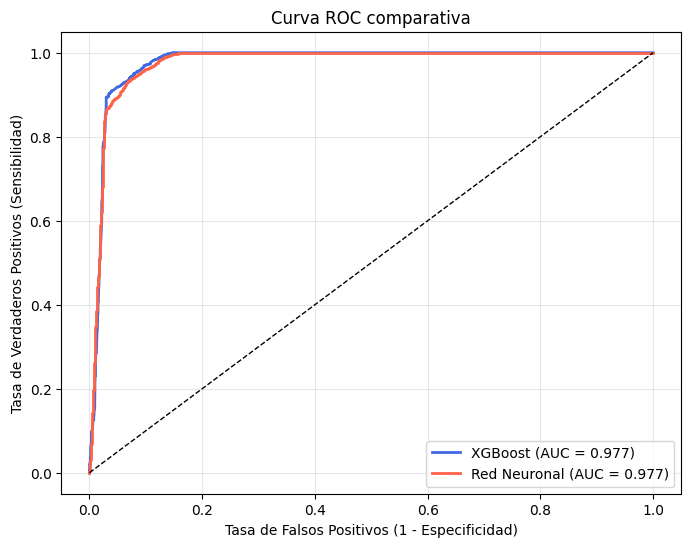

In [ ]:
# Curvas ROC de XGBOOST y MLP
y_pred_proba_xgb = best_modelML.predict_proba(X_test)[:, 1]
y_pred_proba_nn = best_model.predict_proba(X_test)[:, 1]

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_pred_proba_nn)

# AUC
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
roc_auc_nn = auc(fpr_nn, tpr_nn)

# Gráfico conjunto
plt.figure(figsize=(8,6))
plt.plot(fpr_xgb, tpr_xgb, color='royalblue', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.3f})')
plt.plot(fpr_nn, tpr_nn, color='tomato', lw=2, label=f'Red Neuronal (AUC = {roc_auc_nn:.3f})')

plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC comparativa')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


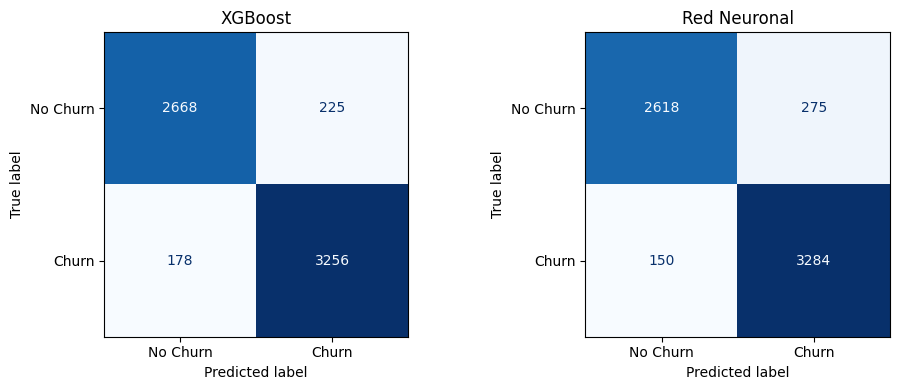

In [ ]:
#Matrix de confusión
# Predicciones binarias
y_pred_xgb = best_modelML.predict(X_test)
y_pred_nn = best_model.predict(X_test)

# Matrices
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
cm_nn = confusion_matrix(y_test, y_pred_nn)

# Mostrar ambas en una misma celda
fig, axes = plt.subplots(1, 2, figsize=(10,4))

ConfusionMatrixDisplay(cm_xgb, display_labels=['No Churn','Churn']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("XGBoost")

ConfusionMatrixDisplay(cm_nn, display_labels=['No Churn','Churn']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title("Red Neuronal")

plt.tight_layout()
plt.show()


In [ ]:
#Joblib XGBoost
joblib.dump(best_modelML, 'best_modelML.joblib')

#Load
best_modelML = joblib.load('best_modelML.joblib')

In [ ]:
"""#Descargo pkl
from google.colab import files
files.download('best_modelML.joblib')"""

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>